In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('RBI_Data_2.0.csv')
data.head()

,Year,Currency_in_circulation_Total,Other_deposits_with_RBI,Bankers_deposits_with_RBI,Reserve_Money_(Liabilities/Components),RBIs_Claims_on_Government(net),RBIs_Claims_on_Central_Govt,RBIs_Claims_on_Banks_and_Commercial_sector,RBIs_Claims_on_Banks_(Including NABARD),RBIs_claims_on_Commercial_sector_(Excluding NABARD),Net_foreign_exchange_assets_of_RBI,Govts_currency_liabilities_to_the_public,Net_non_monetary_liabilities_of_RBI
0,2001-07-06,234802,3980.0,66536,305318,166691.0,NaN,16355.0,7894.0,8461.0,205487.0,5565.0,88780.0
1,2001-07-13,234428,3897.0,70531,308856,166704.0,NaN,21772.0,11751.0,10021.0,205354.0,5565.0,90539.0
2,2001-07-20,231389,3671.0,69480,304540,165737.0,NaN,19405.0,10148.0,9257.0,205404.0,5565.0,91571.0
3,2001-07-27,227989,3517.0,74768,306274,161554.0,NaN,25340.0,13724.0,11616.0,205913.0,5640.0,92173.0
4,2001-08-03,229965,3526.0,67139,300630,164384.0,NaN,16081.0,7750.0,8331.0,206301.0,5640.0,91776.0


In [5]:
data.shape

(1007, 13)

In [7]:
data.tail()

,Year,Currency_in_circulation_Total,Other_deposits_with_RBI,Bankers_deposits_with_RBI,Reserve_Money_(Liabilities/Components),RBIs_Claims_on_Government(net),RBIs_Claims_on_Central_Govt,RBIs_Claims_on_Banks_and_Commercial_sector,RBIs_Claims_on_Banks_(Including NABARD),RBIs_claims_on_Commercial_sector_(Excluding NABARD),Net_foreign_exchange_assets_of_RBI,Govts_currency_liabilities_to_the_public,Net_non_monetary_liabilities_of_RBI
1002,2020-07-24,2670987,39207.0,465767,3175960,1016187.0,1010579.0,254380.0,265960.0,11580.0,3896503.0,26315.0,1508664.0
1003,2020-07-31,2672446,39707.0,469087,3181239,1078662.0,1073847.0,359983.0,371571.0,11588.0,3983510.0,26315.0,1547264.0
1004,2020-08-07,2686070,39755.0,461436,3187260,1075013.0,1065083.0,360149.0,371737.0,11588.0,4017184.0,26315.0,1571102.0
1005,2020-08-14,2691706,39543.0,470719,3201967,979844.0,969138.0,310131.0,321744.0,11613.0,3993710.0,26315.0,1487770.0
1006,2020-08-21,2688322,39769.0,464794,3192884,994754.0,988987.0,346453.0,358066.0,11613.0,4007883.0,26315.0,1489614.0


In [9]:
type(data)

pandas.core.frame.DataFrame

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 13 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Year                                                 1007 non-null   object 
 1   Currency_in_circulation_Total                        1007 non-null   int64  
 2   Other_deposits_with_RBI                              1006 non-null   float64
 3   Bankers_deposits_with_RBI                            1007 non-null   int64  
 4   Reserve_Money_(Liabilities/Components)               1007 non-null   int64  
 5   RBIs_Claims_on_Government(net)                       1006 non-null   float64
 6   RBIs_Claims_on_Central_Govt                          931 non-null    float64
 7   RBIs_Claims_on_Banks_and_Commercial_sector           1006 non-null   float64
 8   RBIs_Claims_on_Banks_(Including NABARD)              1006 non-null  

In [13]:
data['Year'] = pd.to_datetime(data['Year'])

# Data Cleaning

In [15]:
data.isnull().sum()

Year                                                    0
Currency_in_circulation_Total                           0
Other_deposits_with_RBI                                 1
Bankers_deposits_with_RBI                               0
Reserve_Money_(Liabilities/Components)                  0
RBIs_Claims_on_Government(net)                          1
RBIs_Claims_on_Central_Govt                            76
RBIs_Claims_on_Banks_and_Commercial_sector              1
RBIs_Claims_on_Banks_(Including NABARD)                 1
RBIs_claims_on_Commercial_sector_(Excluding NABARD)     1
Net_foreign_exchange_assets_of_RBI                      1
Govts_currency_liabilities_to_the_public                1
Net_non_monetary_liabilities_of_RBI                     1
dtype: int64

In [17]:
data.isnull().sum().sum()

84

In [19]:
# Percentage null values

(data.isnull().sum() / data.shape[0]) * 100

Year                                                   0.000000
Currency_in_circulation_Total                          0.000000
Other_deposits_with_RBI                                0.099305
Bankers_deposits_with_RBI                              0.000000
Reserve_Money_(Liabilities/Components)                 0.000000
RBIs_Claims_on_Government(net)                         0.099305
RBIs_Claims_on_Central_Govt                            7.547170
RBIs_Claims_on_Banks_and_Commercial_sector             0.099305
RBIs_Claims_on_Banks_(Including NABARD)                0.099305
RBIs_claims_on_Commercial_sector_(Excluding NABARD)    0.099305
Net_foreign_exchange_assets_of_RBI                     0.099305
Govts_currency_liabilities_to_the_public               0.099305
Net_non_monetary_liabilities_of_RBI                    0.099305
dtype: float64

In [21]:
# Total percentage of null values

((data.isnull().sum().sum()) / (data.shape[0] * data.shape[1])) * 100

0.6416622106790926

In [23]:
data.columns

Index(['Year', 'Currency_in_circulation_Total', 'Other_deposits_with_RBI',
       'Bankers_deposits_with_RBI', 'Reserve_Money_(Liabilities/Components)',
       'RBIs_Claims_on_Government(net)', 'RBIs_Claims_on_Central_Govt',
       'RBIs_Claims_on_Banks_and_Commercial_sector',
       'RBIs_Claims_on_Banks_(Including NABARD)',
       'RBIs_claims_on_Commercial_sector_(Excluding NABARD)',
       'Net_foreign_exchange_assets_of_RBI',
       'Govts_currency_liabilities_to_the_public',
       'Net_non_monetary_liabilities_of_RBI'],
      dtype='object')

In [25]:
data.set_index('Year', inplace = True)

In [41]:
data

,Currency_in_circulation_Total,Other_deposits_with_RBI,Bankers_deposits_with_RBI,Reserve_Money_(Liabilities/Components),RBIs_Claims_on_Government(net),RBIs_Claims_on_Central_Govt,RBIs_Claims_on_Banks_and_Commercial_sector,RBIs_Claims_on_Banks_(Including NABARD),RBIs_claims_on_Commercial_sector_(Excluding NABARD),Net_foreign_exchange_assets_of_RBI,Govts_currency_liabilities_to_the_public,Net_non_monetary_liabilities_of_RBI
Year,,,,,,,,,,,,
2001-07-06,234802,3980.0,66536,305318,166691.0,NaN,16355.0,7894.0,8461.0,205487.0,5565.0,88780.0
2001-07-13,234428,3897.0,70531,308856,166704.0,NaN,21772.0,11751.0,10021.0,205354.0,5565.0,90539.0
2001-07-20,231389,3671.0,69480,304540,165737.0,NaN,19405.0,10148.0,9257.0,205404.0,5565.0,91571.0
2001-07-27,227989,3517.0,74768,306274,161554.0,NaN,25340.0,13724.0,11616.0,205913.0,5640.0,92173.0
2001-08-03,229965,3526.0,67139,300630,164384.0,NaN,16081.0,7750.0,8331.0,206301.0,5640.0,91776.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-07-24,2670987,39207.0,465767,3175960,1016187.0,1010579.0,254380.0,265960.0,11580.0,3896503.0,26315.0,1508664.0
2020-07-31,2672446,39707.0,469087,3181239,1078662.0,1073847.0,359983.0,371571.0,11588.0,3983510.0,26315.0,1547264.0
2020-08-07,2686070,39755.0,461436,3187260,1075013.0,1065083.0,360149.0,371737.0,11588.0,4017184.0,26315.0,1571102.0


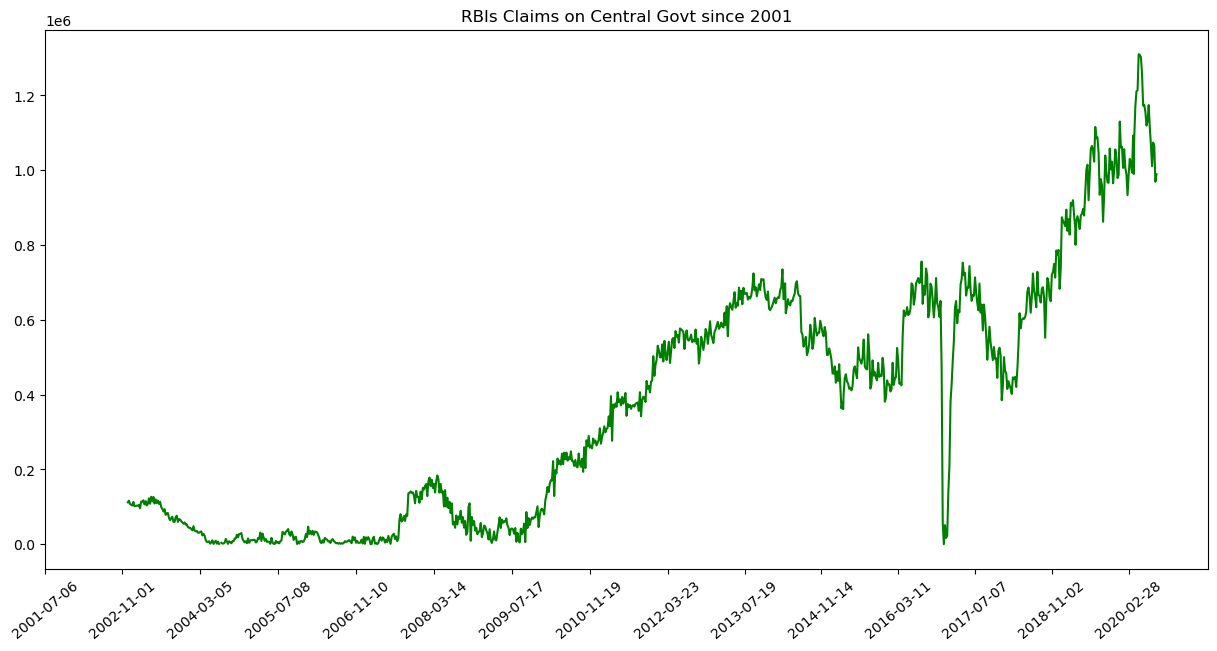

In [29]:
plt.rcParams['figure.figsize']=(15,7)

# plots our series
plt.plot(data['RBIs_Claims_on_Central_Govt'], color='green')
plt.xticks(data.index[::70],  rotation=40)
plt.title('RBIs Claims on Central Govt since 2001') 

plt.show()

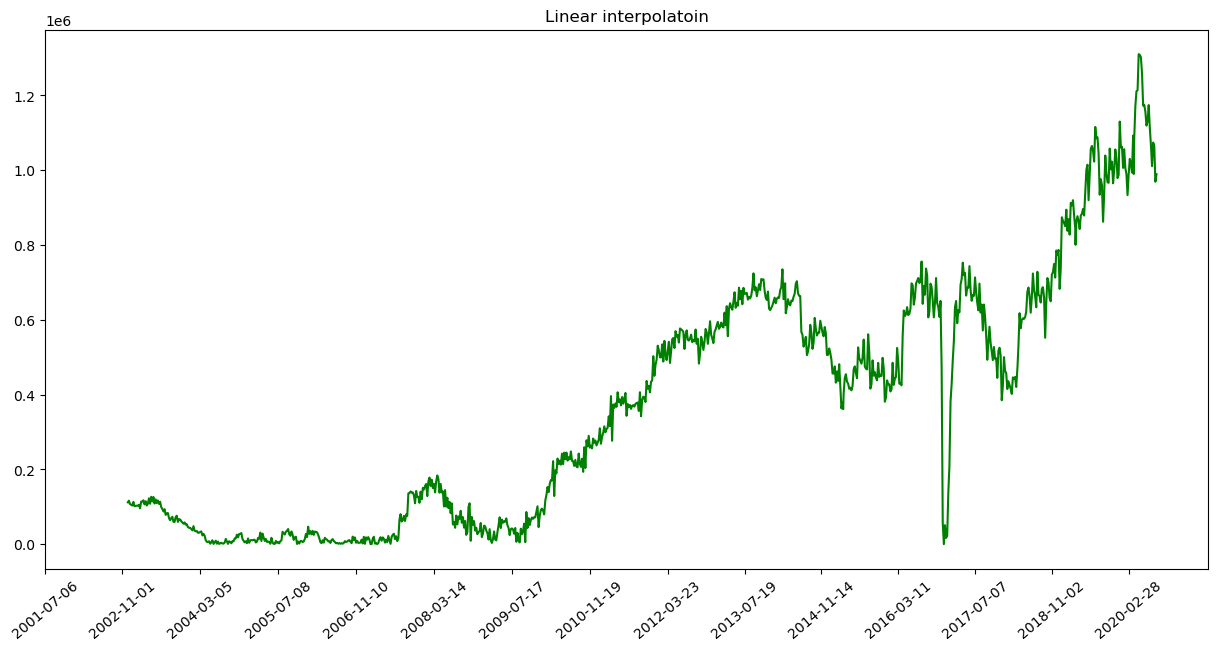

In [31]:
# Imputing the missing values
## Linear Interopolation

plt.rcParams['figure.figsize']=(15,7)
 
# on our data, impute the missing values using rolling window method
data_linear_interp = data.interpolate(method='linear')
 
# plot the complete dataset
plt.plot(data_linear_interp['RBIs_Claims_on_Central_Govt'], color='green')
plt.xticks(data_linear_interp.index[::70],  rotation=40)

plt.title('Linear interpolatoin')
plt.show()

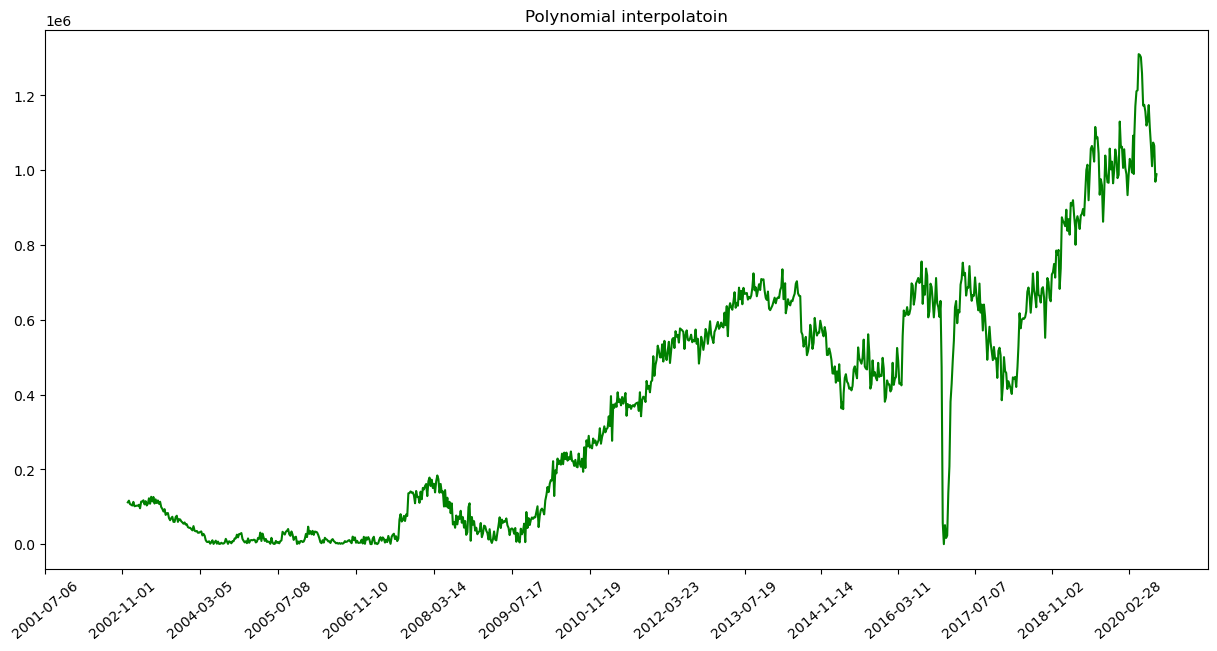

In [35]:
## Polynomial Interpolation

plt.rcParams['figure.figsize']=(15,7)
 
# on our data, impute the missing values using rolling window method
data_poly_interp = data.interpolate(method='polynomial', order = 2)
 
# plot the complete dataset
plt.plot(data_poly_interp['RBIs_Claims_on_Central_Govt'], color='green')
plt.xticks(data_poly_interp.index[::70],  rotation=40)
plt.title('Polynomial interpolatoin')
plt.show()

C:\Users\rbhat\anaconda3\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)
C:\Users\rbhat\anaconda3\Lib\site-packages\pandas\core\missing.py:604: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  terp = interpolate.UnivariateSpline(x, y, k=order, **kwargs)


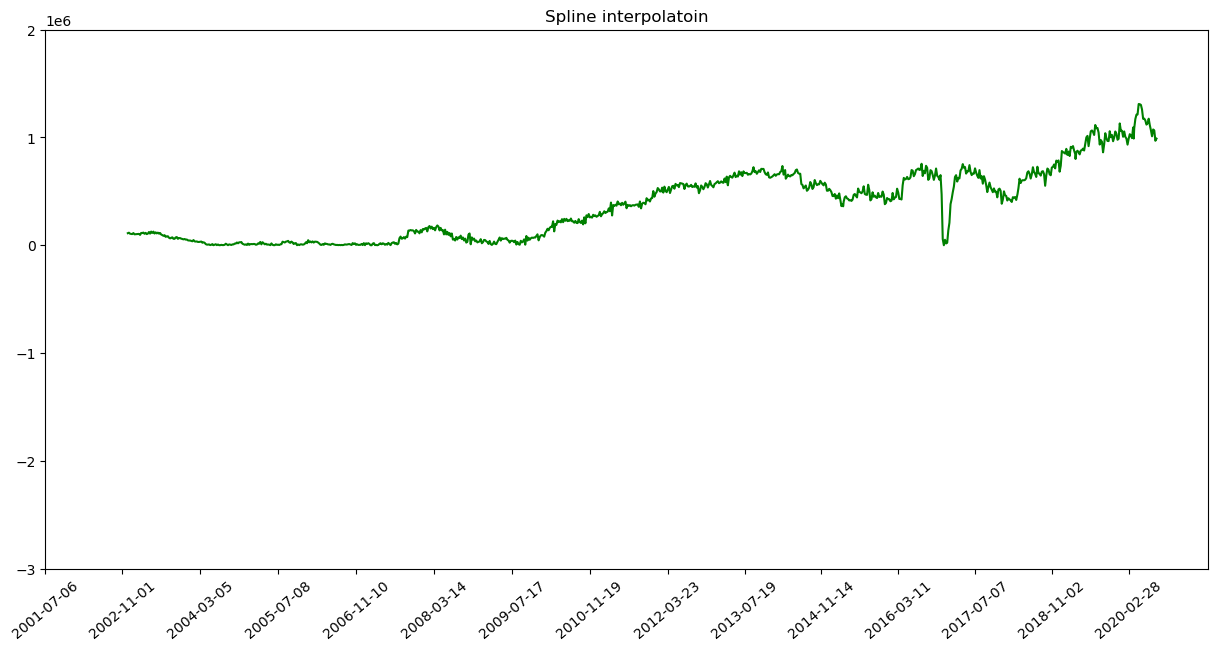

In [39]:
## Spline Interpolation

plt.rcParams['figure.figsize']=(15,7)
 
# on our data, impute the missing values using rolling window method
data_spline_interp = data.interpolate(method='spline', order = 2)
 
# plot the complete dataset
plt.plot(data_spline_interp['RBIs_Claims_on_Central_Govt'], color='green')
plt.xticks(data.index[::70],  rotation=40)
plt.ylim(-3000000,2000000)
plt.title('Spline interpolatoin')
plt.show()

In [43]:
!pip install fancyimpute pandas numpy scikit-learn

In [45]:
## Expectation-Maximization Imputation

import pandas as pd
import numpy as np
from fancyimpute import IterativeImputer

# Display missing values before imputation
print("Missing values before imputation:")
print(data.isnull().sum())

# Select numerical columns only for imputation
num_cols = data.select_dtypes(include=[np.number]).columns

# Apply EM-based imputation (IterativeImputer uses Bayesian Ridge regression)
imputer = IterativeImputer(max_iter=10, random_state=42)
data[num_cols] = imputer.fit_transform(data[num_cols])

# Display missing values after imputation
print("\nMissing values after imputation:")
print(data.isnull().sum())

Missing values before imputation:
Currency_in_circulation_Total                           0
Other_deposits_with_RBI                                 1
Bankers_deposits_with_RBI                               0
Reserve_Money_(Liabilities/Components)                  0
RBIs_Claims_on_Government(net)                          1
RBIs_Claims_on_Central_Govt                            76
RBIs_Claims_on_Banks_and_Commercial_sector              1
RBIs_Claims_on_Banks_(Including NABARD)                 1
RBIs_claims_on_Commercial_sector_(Excluding NABARD)     1
Net_foreign_exchange_assets_of_RBI                      1
Govts_currency_liabilities_to_the_public                1
Net_non_monetary_liabilities_of_RBI                     1
dtype: int64

Missing values after imputation:
Currency_in_circulation_Total                          0
Other_deposits_with_RBI                                0
Bankers_deposits_with_RBI                              0
Reserve_Money_(Liabilities/Components)              

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1007 entries, 2001-07-06 to 2020-08-21
Data columns (total 12 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Currency_in_circulation_Total                        1007 non-null   float64
 1   Other_deposits_with_RBI                              1007 non-null   float64
 2   Bankers_deposits_with_RBI                            1007 non-null   float64
 3   Reserve_Money_(Liabilities/Components)               1007 non-null   float64
 4   RBIs_Claims_on_Government(net)                       1007 non-null   float64
 5   RBIs_Claims_on_Central_Govt                          1007 non-null   float64
 6   RBIs_Claims_on_Banks_and_Commercial_sector           1007 non-null   float64
 7   RBIs_Claims_on_Banks_(Including NABARD)              1007 non-null   float64
 8   RBIs_claims_on_Commercial_sector_(Excluding NABARD

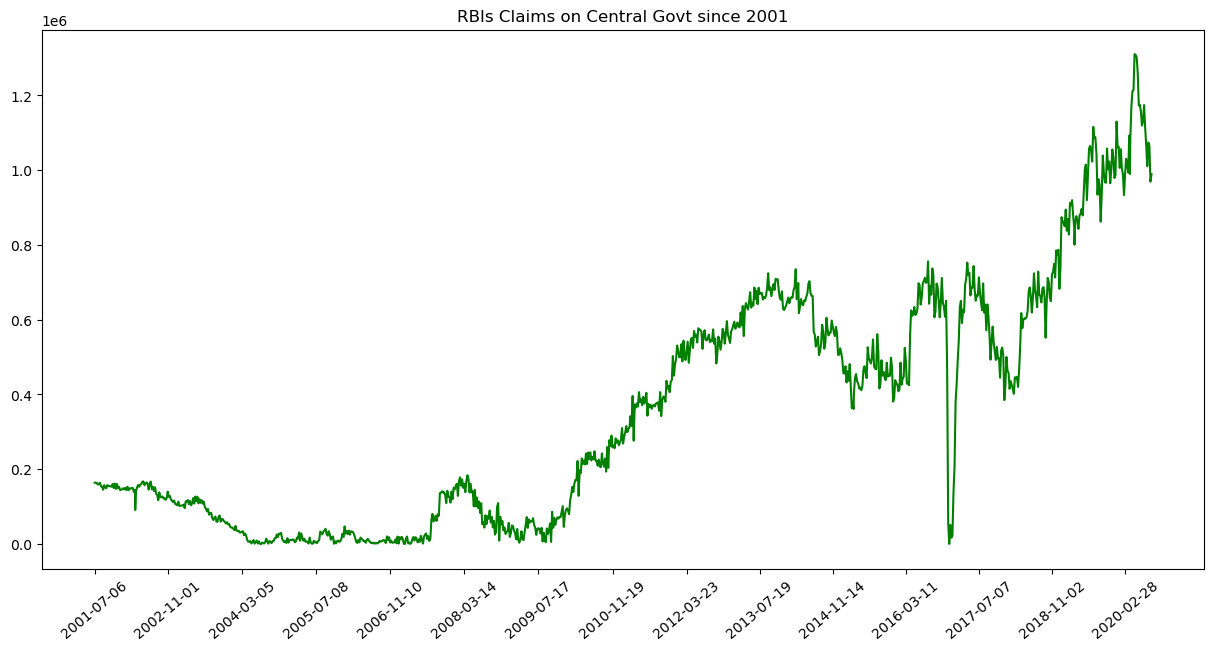

<Figure size 1500x700 with 0 Axes>

In [49]:
plt.rcParams['figure.figsize']=(15,7)

# plots our series
plt.plot(data['RBIs_Claims_on_Central_Govt'], color='green')
plt.xticks(data.index[::70],  rotation=40)
plt.title('RBIs Claims on Central Govt since 2001') 

plt.show()
plt.savefig('Sample1.png')

# Exploratory Data Analysis

## A. Line Diagram

### 1. Currency in Circulation Trend Plot


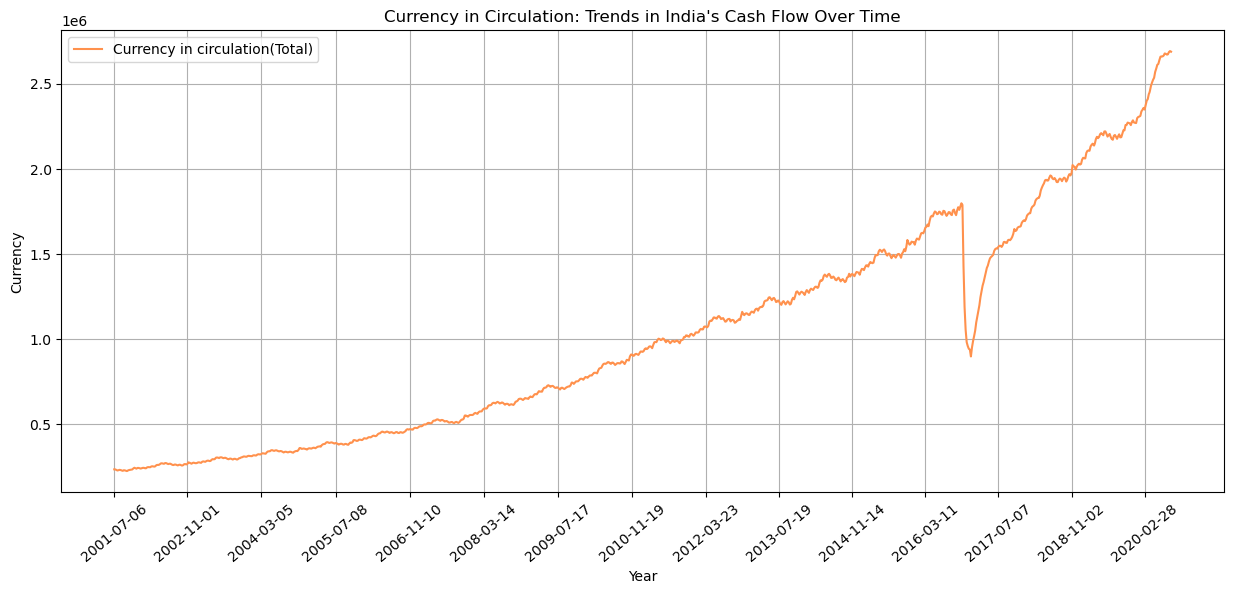

In [51]:
plt.figure(figsize = (15, 6))
plt.plot(data['Currency_in_circulation_Total'], label = 'Currency in circulation(Total)', color = '#FF914D')
plt.title("Currency in Circulation: Trends in India's Cash Flow Over Time")
plt.xticks(data.index[::70],  rotation=40)
plt.xlabel('Year')
plt.ylabel('Currency')
plt.legend()
plt.grid(True)
plt.savefig('Sample1.png')
plt.show()

## Insights from the Currency in Circulation Trend Plot
1. India’s economy has seen a long-term increase in currency usage.
2. Around 2016-2017, the demonetization event caused a temporary drop but was followed by a quick recovery.
3. Post-2018, currency circulation has increased at a faster rate, possibly due to economic expansion and financial uncertainties.

### 2. Reserve Money Trend Plot

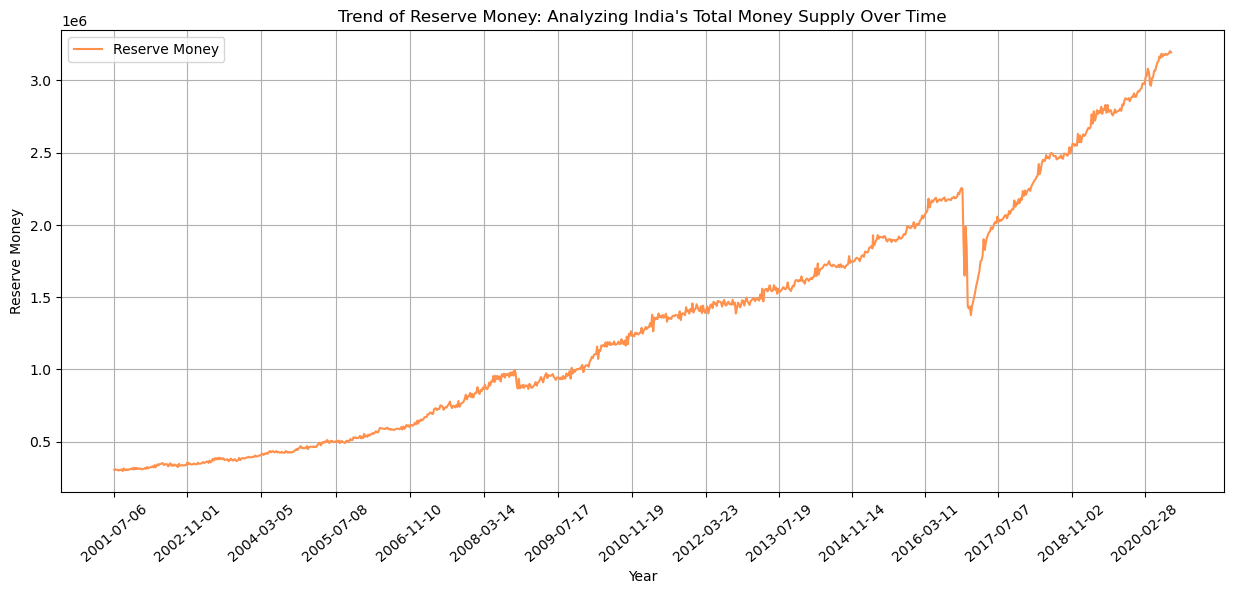

In [53]:
plt.figure(figsize = (15, 6))
plt.plot(data.index, data['Reserve_Money_(Liabilities/Components)'], label = 'Reserve Money', color = '#FF914D')
plt.title("Trend of Reserve Money: Analyzing India's Total Money Supply Over Time")
plt.xticks(data.index[::70],  rotation=40)
plt.xlabel('Year')
plt.ylabel('Reserve Money')
plt.legend()
plt.grid(True)
plt.savefig('Sample2.png')
plt.show()

## Insights from the Reserve Money Trend Plot
1. Long-term rise in Reserve Money reflects India's growing economy and RBI’s liquidity management.
2. Demonetization in 2016 caused a sharp dip, but the system recovered quickly.
3. Post-2018, Reserve Money expanded rapidly, possibly due to economic policies and government spending.
4. The COVID-19 period saw an even steeper increase, likely due to RBI's interventions to maintain stability.

### 3. Foreign Exchange Reserves Trend of RBI

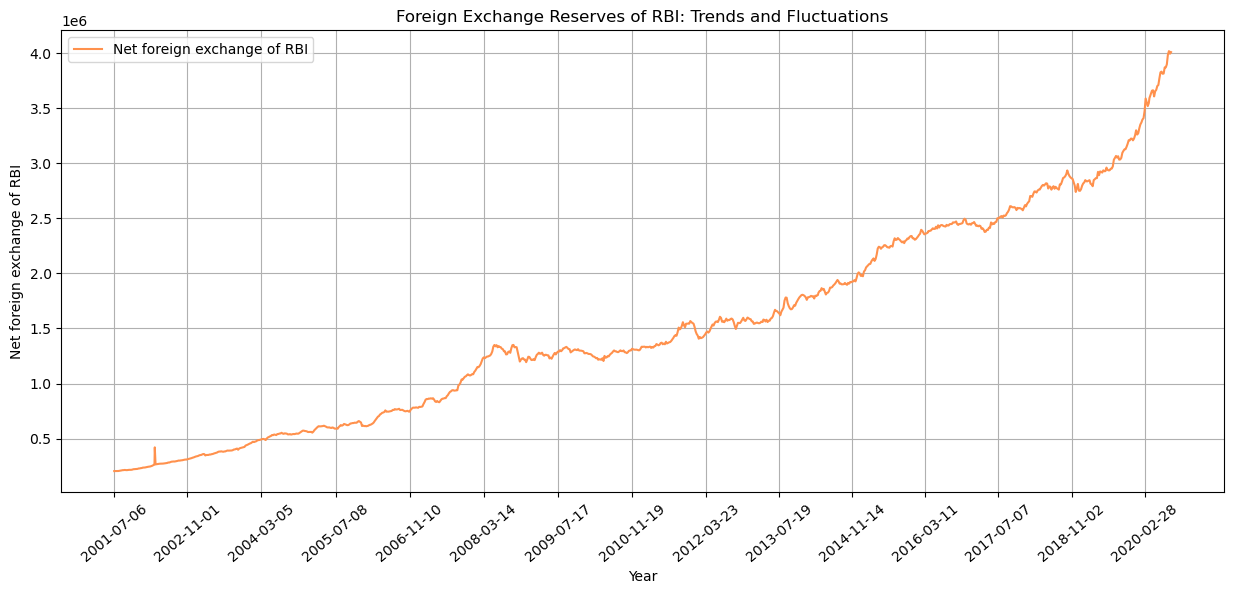

In [55]:
plt.figure(figsize = (15, 6))
plt.plot(data.index, data['Net_foreign_exchange_assets_of_RBI'], label = 'Net foreign exchange of RBI', color = '#FF914D')
plt.title('Foreign Exchange Reserves of RBI: Trends and Fluctuations')
plt.xticks(data.index[::70],  rotation=40)
plt.xlabel('Year')
plt.ylabel('Net foreign exchange of RBI')
plt.legend()
plt.grid(True)
plt.savefig('Sample3.png')
plt.show()

## Insights from the Foreign Exchange Reserves Trend of RBI
1. India’s forex reserves have grown significantly over two decades, reflecting strong foreign exchange policies.
2. Global financial crises (2008) caused fluctuations, but RBI managed to stabilize reserves over time.
3. Post-2019, reserves have grown faster, possibly due to increased global capital inflows and India’s economic resilience.
4. High forex reserves provide economic stability, helping India manage external shocks and maintain currency strength.


### 4. Trend plot of Bankers' Deposits with RBI

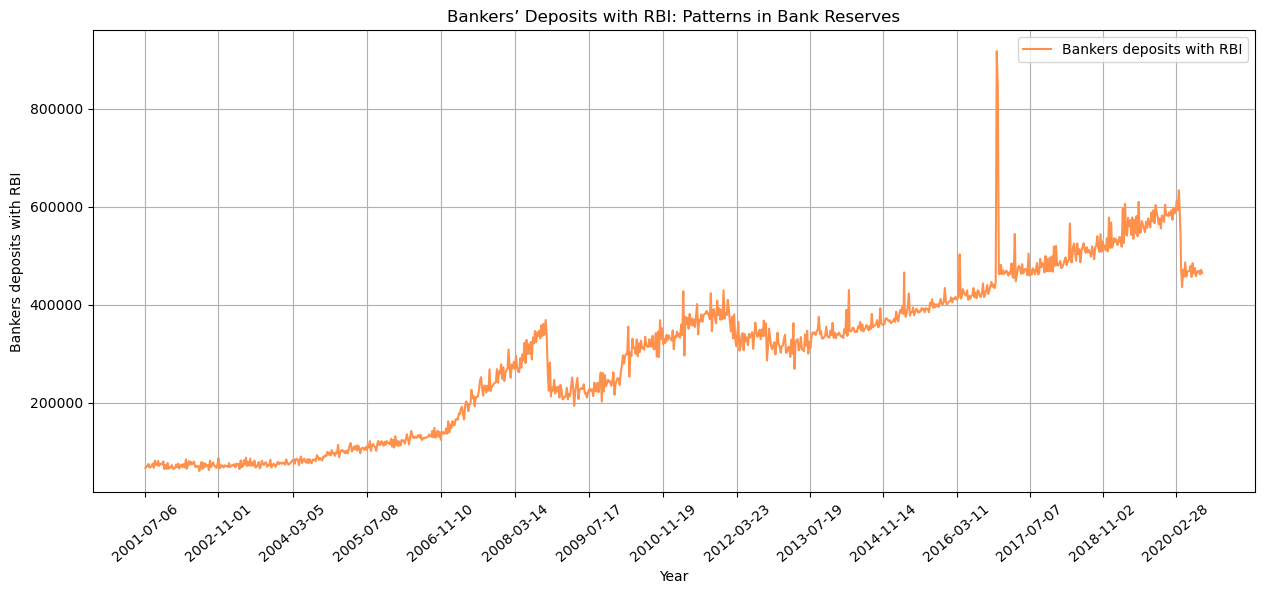

In [57]:
plt.figure(figsize = (15, 6))
plt.plot(data.index, data['Bankers_deposits_with_RBI'], label = 'Bankers deposits with RBI', color = '#FF914D')
plt.title("Bankers’ Deposits with RBI: Patterns in Bank Reserves")
plt.xticks(data.index[::70],  rotation=40)
plt.xlabel('Year')
plt.ylabel('Bankers deposits with RBI')
plt.legend()
plt.grid(True)
plt.savefig('Sample4.png')
plt.show()

## Insights from the Bankers' Deposits with RBI
1. Bankers’ deposits with RBI have grown over time, reflecting a strengthening banking system.
2. Sharp fluctuations indicate liquidity adjustments, policy impacts, and economic shocks.
3. The 2016-2017 demonetization caused a huge spike in reserves, as banks deposited excess cash.
4. Post-2019, reserves are volatile, suggesting active liquidity management by RBI.

### 5. Trend plot of RBI’s Net Claims on Government

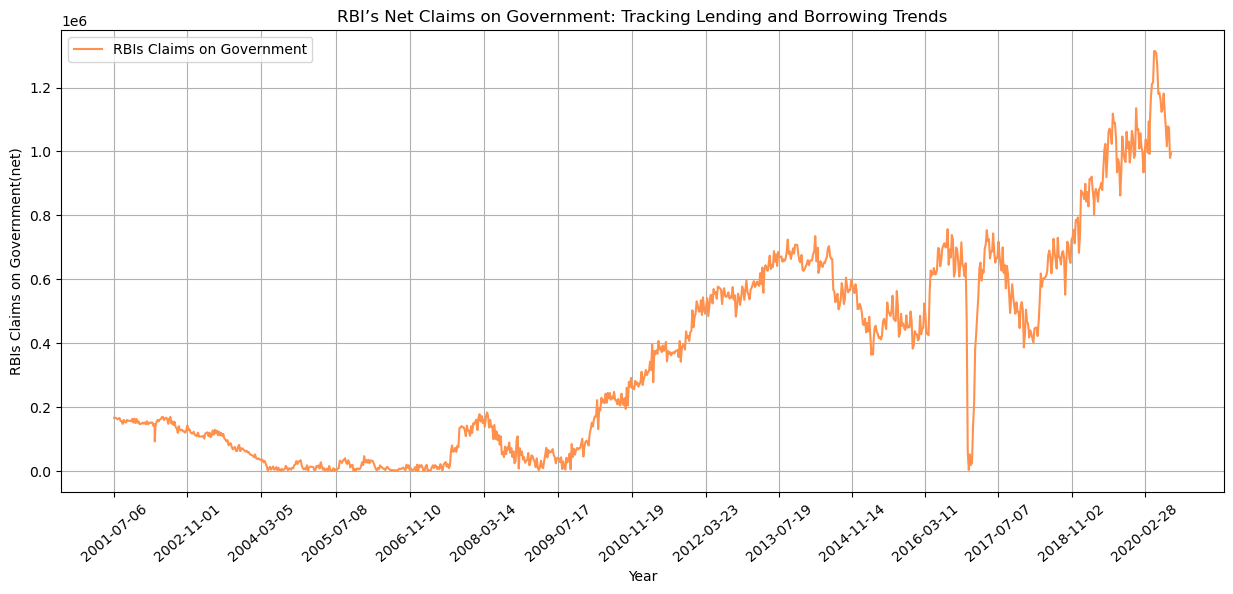

In [59]:
plt.figure(figsize = (15, 6))
plt.plot(data.index, data['RBIs_Claims_on_Government(net)'], label = 'RBIs Claims on Government', color = '#FF914D')
plt.title("RBI’s Net Claims on Government: Tracking Lending and Borrowing Trends")
plt.xticks(data.index[::70],  rotation=40)
plt.xlabel('Year')
plt.ylabel('RBIs Claims on Government(net)')
plt.legend()
plt.grid(True)
plt.savefig('Sample5.png')
plt.show()

## Insights from RBI’s Net Claims on Government
1. Government borrowing from RBI decreased until 2007 but surged after the 2008 financial crisis.
2. Post-2010, RBI’s claims on the government steadily increased, indicating higher fiscal deficits
3. A sudden drop around 2016-2017 suggests loan repayments, possibly due to demonetization.
4. Post-2018, borrowing peaked, likely due to economic challenges and COVID-19 stimulus measures.

## B. Rolling Mean & Standard Deviations

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1. Rolling Mean & Standard Deviation Plot of Currency in Circulation


In [63]:
A = pd.DataFrame(data.Currency_in_circulation_Total)
A['MA_7'] = A.Currency_in_circulation_Total.rolling(7).mean()
A['MA_30'] = A.Currency_in_circulation_Total.rolling(30).mean()
A['MA_90'] = A.Currency_in_circulation_Total.rolling(90).mean()

A['MA_7_std'] = A.Currency_in_circulation_Total.rolling(7).std()
A['MA_30_std'] = A.Currency_in_circulation_Total.rolling(30).std()
A['MA_90_std'] = A.Currency_in_circulation_Total.rolling(90).std()

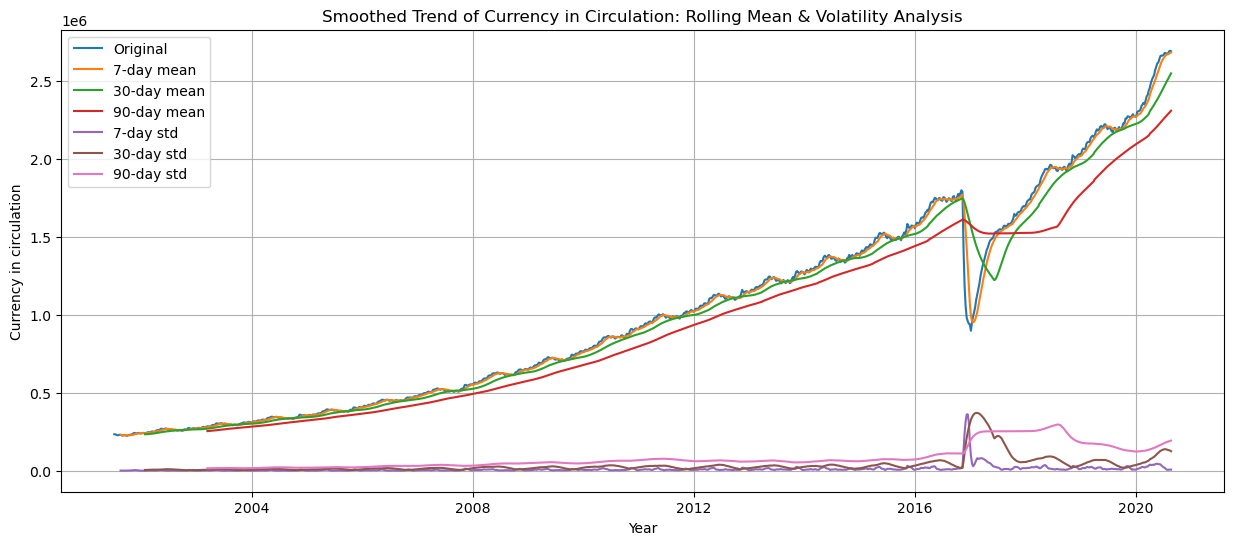

In [65]:
plt.figure(figsize = (15,6))
plt.grid(True)
plt.plot(A['Currency_in_circulation_Total'], label = 'Original')
plt.plot(A['MA_7'], label = '7-day mean')
plt.plot(A['MA_30'], label = '30-day mean')
plt.plot(A['MA_90'], label = '90-day mean')

plt.plot(A['MA_7_std'], label = '7-day std')
plt.plot(A['MA_30_std'], label = '30-day std')
plt.plot(A['MA_90_std'], label = '90-day std')
plt.title('Smoothed Trend of Currency in Circulation: Rolling Mean & Volatility Analysis')
plt.xlabel('Year')
plt.ylabel('Currency in circulation')
plt.legend(loc = 2)
plt.savefig('Rm_std1')
plt.show()

### Insights from the Rolling Mean & Standard Deviation Plot of Currency in Circulation
1. The blue line (original data) shows a consistent increase in the amount of currency in circulation over time.
2. The 7-day, 30-day, and 90-day moving averages (orange, green, and red lines) confirm this long-term growth trend.
3. The rolling means (30-day and 90-day) also drop but recover gradually, suggesting a temporary liquidity shock.
4. The standard deviation (std) lines (purple, brown, pink) represent fluctuations in currency circulation.

### 2. Rolling Mean & Standard Deviation Plot of Reserve Money

In [67]:
B = pd.DataFrame(data['Reserve_Money_(Liabilities/Components)'])
B['MA_7'] = B['Reserve_Money_(Liabilities/Components)'].rolling(7).mean()
B['MA_30'] = B['Reserve_Money_(Liabilities/Components)'].rolling(30).mean()
B['MA_90'] = B['Reserve_Money_(Liabilities/Components)'].rolling(90).mean()

B['7_std'] = B['Reserve_Money_(Liabilities/Components)'].rolling(7).std()
B['30_std'] = B['Reserve_Money_(Liabilities/Components)'].rolling(30).std()
B['90_std'] = B['Reserve_Money_(Liabilities/Components)'].rolling(90).std()

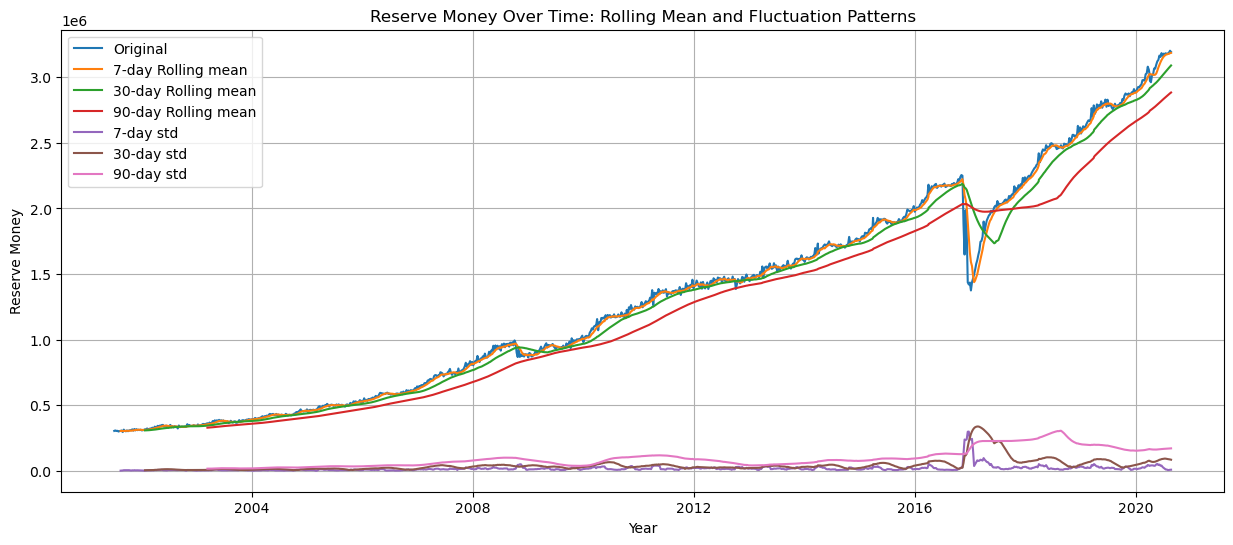

In [69]:
plt.figure(figsize = (15,6))
plt.grid(True)
plt.plot(B['Reserve_Money_(Liabilities/Components)'], label = 'Original')
plt.plot(B['MA_7'], label = '7-day Rolling mean')
plt.plot(B['MA_30'], label = '30-day Rolling mean')
plt.plot(B['MA_90'], label = '90-day Rolling mean')

plt.plot(B['7_std'], label = '7-day std')
plt.plot(B['30_std'], label = '30-day std')
plt.plot(B['90_std'], label = '90-day std')
plt.title('Reserve Money Over Time: Rolling Mean and Fluctuation Patterns')
plt.xlabel('Year')
plt.ylabel('Reserve Money')
plt.legend(loc = 2)
plt.savefig('Rm_std2')
plt.show()

### Insights from the Rolling Mean & Standard Deviation Plot of Reserve Money
1. The 7-day, 30-day, and 90-day rolling means (orange, green, and red lines) smooth out short-term fluctuations, confirming a consistent upward trend.
2. The standard deviation (std) lines (purple, brown, pink) represent fluctuations in Reserve Money.
3. For most of the period, volatility remains low, indicating stable reserve money growth.
4. Lower volatility post-2017 indicates that monetary stability was restored and RBI maintained a steady expansion of Reserve Money.

### 3. Rolling Mean & Standard Deviation Plot of Net Foreign Exchange Assets of RBI

In [71]:
C = pd.DataFrame(data.Net_foreign_exchange_assets_of_RBI)
C['MA_7'] = C.Net_foreign_exchange_assets_of_RBI.rolling(7).mean()
C['MA_30'] = C.Net_foreign_exchange_assets_of_RBI.rolling(30).mean()
C['MA_90'] = C.Net_foreign_exchange_assets_of_RBI.rolling(90).mean()

C['7_std'] = C.Net_foreign_exchange_assets_of_RBI.rolling(7).std()
C['30_std'] = C.Net_foreign_exchange_assets_of_RBI.rolling(30).std()
C['90_std'] = C.Net_foreign_exchange_assets_of_RBI.rolling(90).std()

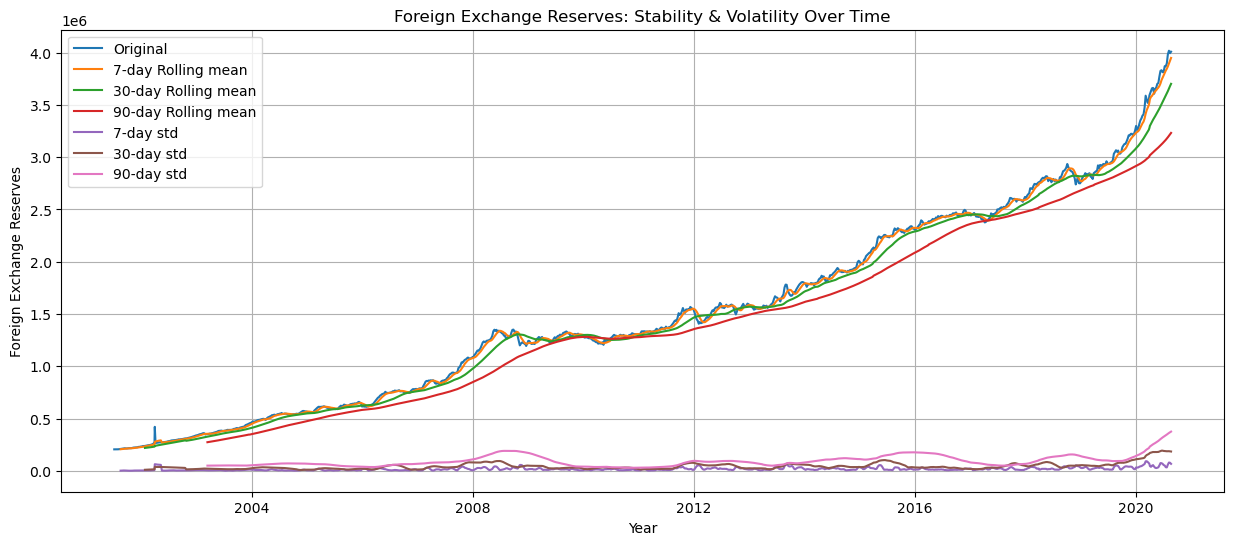

In [73]:
plt.figure(figsize = (15,6))
plt.grid(True)
plt.plot(C['Net_foreign_exchange_assets_of_RBI'], label = 'Original')
plt.plot(C['MA_7'], label = '7-day Rolling mean')
plt.plot(C['MA_30'], label = '30-day Rolling mean')
plt.plot(C['MA_90'], label = '90-day Rolling mean')

plt.plot(C['7_std'], label = '7-day std')
plt.plot(C['30_std'], label = '30-day std')
plt.plot(C['90_std'], label = '90-day std')
plt.title('Foreign Exchange Reserves: Stability & Volatility Over Time')
plt.xlabel('Year')
plt.ylabel('Foreign Exchange Reserves')
plt.legend(loc = 2)
plt.savefig('Rm_std3')
plt.show()

### Insights from the Rolling Mean & Standard Deviation Plot of Net Foreign Exchange Assets of RBI
1. The 7-day, 30-day, and 90-day rolling means (orange, green, and red lines) smooth out fluctuations and confirm the upward trend.
2. Between 2008-2009, there is a sharp dip, likely due to the Global Financial Crisis, which caused capital outflows and a decline in forex reserves.
3. The volatility remains moderate but stable, showing that RBI has effectively managed forex fluctuations.
4. A spike in volatility is seen around 2020, possibly due to the COVID-19 pandemic, which led to global economic uncertainty, currency fluctuations, and large capital movements.


### 4. Rolling Mean & Standard Deviation Plot of Bankers’ Deposits with RBI

In [75]:
D = pd.DataFrame(data.Bankers_deposits_with_RBI)
D['MA_7'] = D.Bankers_deposits_with_RBI.rolling(7).mean()
D['MA_30'] = D.Bankers_deposits_with_RBI.rolling(30).mean()
D['MA_90'] = D.Bankers_deposits_with_RBI.rolling(90).mean()

D['7_std'] = D.Bankers_deposits_with_RBI.rolling(7).std()
D['30_std'] = D.Bankers_deposits_with_RBI.rolling(30).std()
D['90_std'] = D.Bankers_deposits_with_RBI.rolling(90).std()

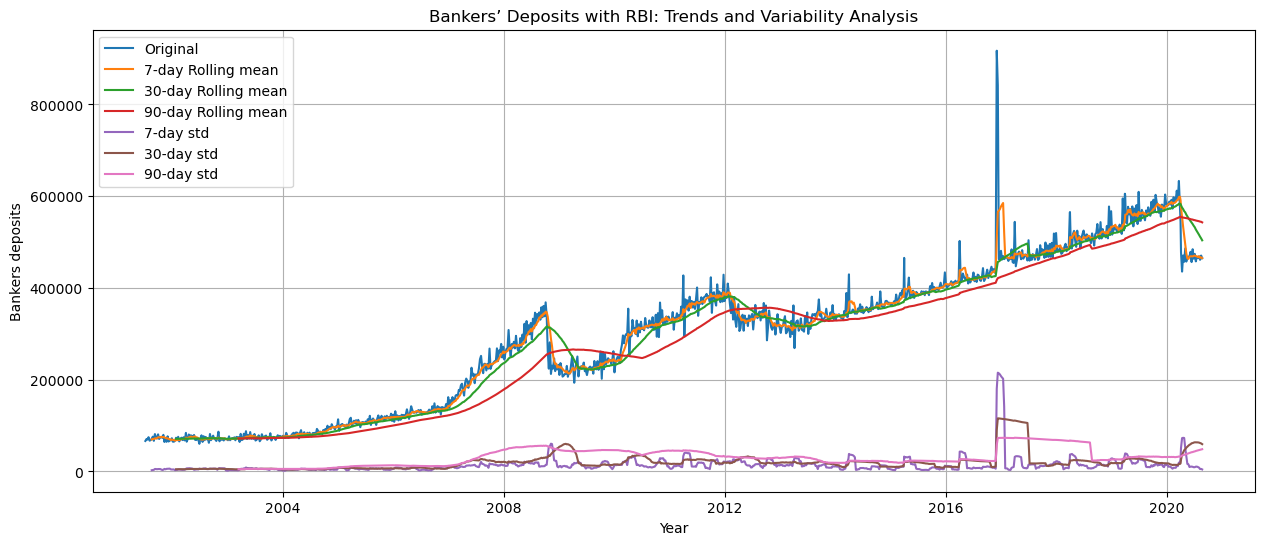

In [77]:
plt.figure(figsize = (15,6))
plt.grid(True)
plt.plot(D['Bankers_deposits_with_RBI'], label = 'Original')
plt.plot(D['MA_7'], label = '7-day Rolling mean')
plt.plot(D['MA_30'], label = '30-day Rolling mean')
plt.plot(D['MA_90'], label = '90-day Rolling mean')

plt.plot(D['7_std'], label = '7-day std')
plt.plot(D['30_std'], label = '30-day std')
plt.plot(D['90_std'], label = '90-day std')
plt.title( "Bankers’ Deposits with RBI: Trends and Variability Analysis")
plt.xlabel('Year')
plt.ylabel('Bankers deposits')
plt.legend(loc = 2)
plt.savefig('Rm_std4')
plt.show()

### Insights from the Rolling Mean & Standard Deviation Plot of Bankers’ Deposits with RBI
1. The rolling means (7-day, 30-day, and 90-day) (orange, green, and red lines) smooth out the fluctuations, confirming the gradual increase in deposits.
2. This indicates that banks have been depositing more funds with the RBI over the years, likely due to higher reserve requirements, increased banking activity, or economic expansion.
3. There are clear phases where deposits decline significantly.
4. The standard deviation (std) lines (purple, brown, pink) show that fluctuations in deposits have become more pronounced after 2008.

## Time Series Decomposition

### 1. Currency in Circulation: Seasonal Decomposition Analysis
Here we use STL Decomposition, as from the trend plot it is clear that the seasonal variation is not directly proportonal to currency in circulation. So we can conclude this as an additive model.

In [203]:
from statsmodels.tsa.seasonal import STL

# Perfrom STL decomposition
stl = STL(data['Currency_in_circulation_Total'], period = 30)
result = stl.fit()

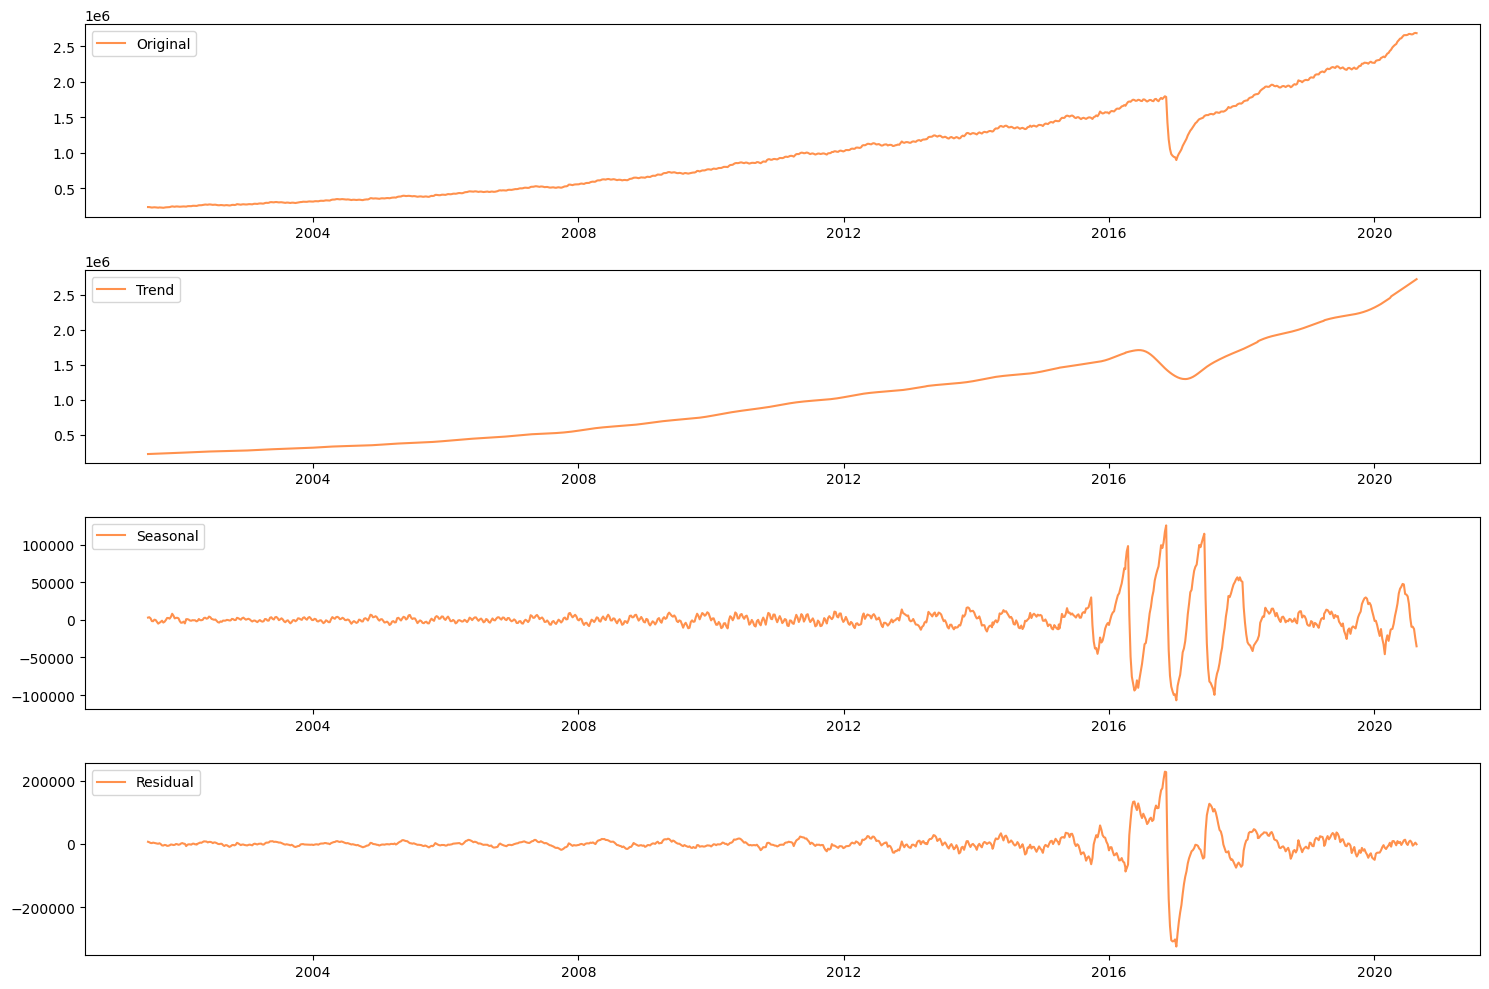

In [205]:
# Plot the decomposition components
plt.figure(figsize = (15,10))
plt.subplot(411)
plt.plot(result.observed, label = 'Original', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(result.trend, label = 'Trend', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(result.seasonal, label = 'Seasonal', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(result.resid, label = 'Residual', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig('STL1')
plt.show()

### Seasonal Decomposition Analysis of Currency in Circulation:
1. The overall trend shows a steady increase in currency circulation over time.
2. Regular seasonal fluctuations are present throughout the timeline.
3. Increased seasonal variations are seen post-2016, indicating higher short-term fluctuations in currency demand.
4. The residuals are relatively stable until 2016, after which they exhibit high volatility, coinciding with the demonetization event.

### 2. Bankers' Deposits with RBI: Seasonal Decomposition Analysis

Here we use STL Decomposition, as from the trend plot it is clear that the seasonal variation is not directly proportonal to Bankers' deposits. So we can conclude this as an additive model.

In [207]:
from statsmodels.tsa.seasonal import STL

# Perfrom STL decomposition
stl = STL(data['Bankers_deposits_with_RBI'], period = 30)
result = stl.fit()

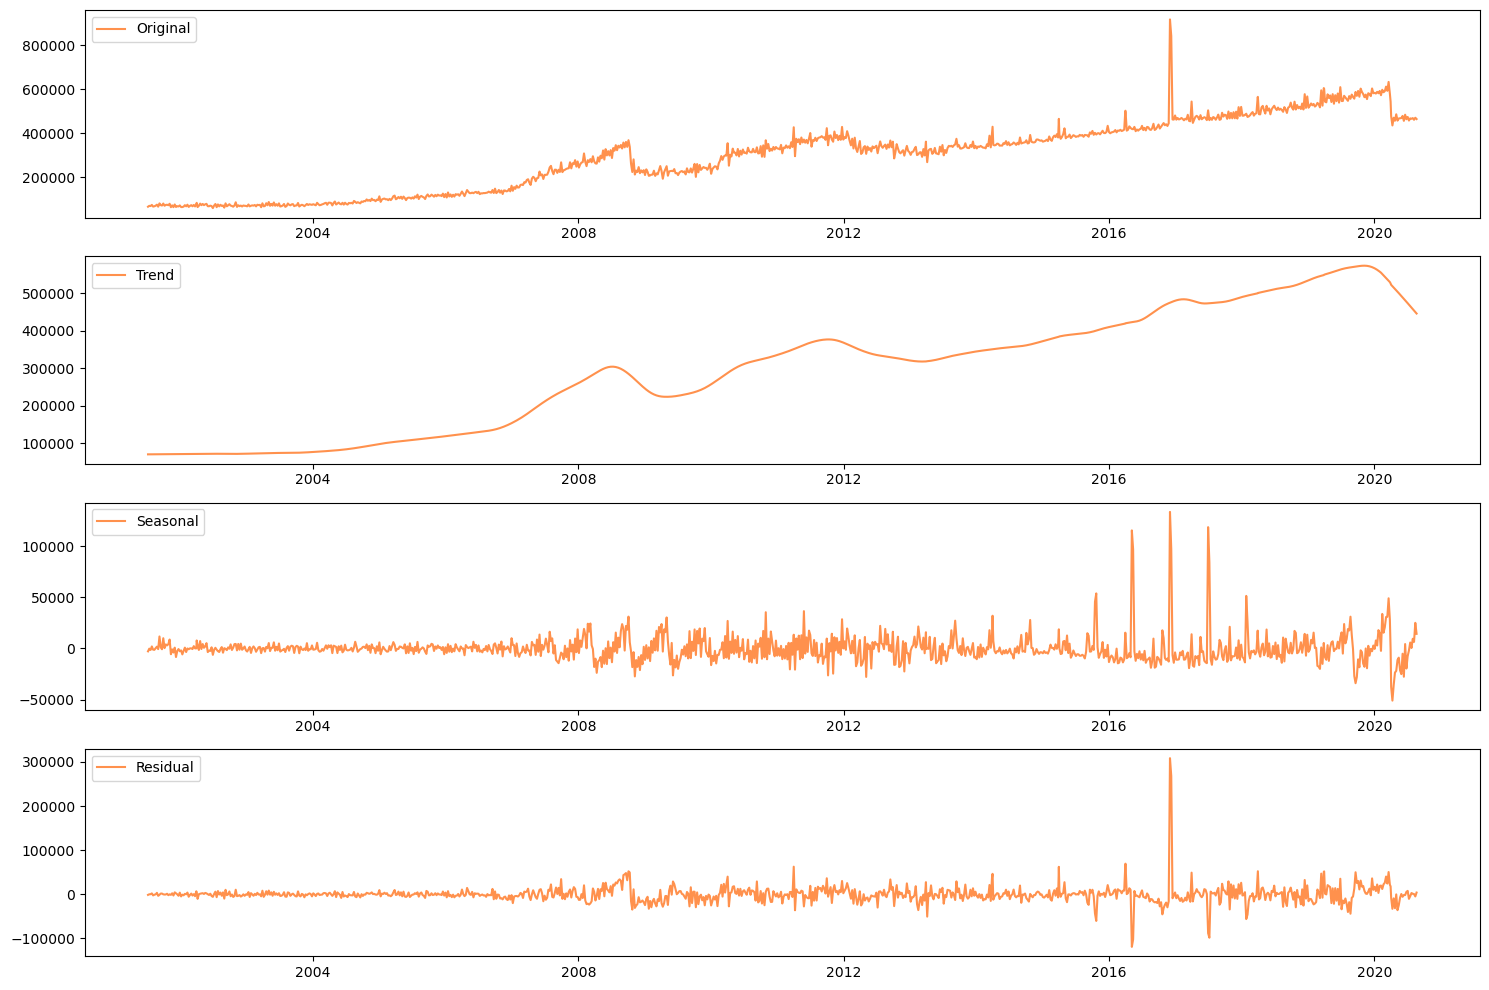

In [209]:
# Plot the decomposition components
plt.figure(figsize = (15,10))
plt.subplot(411)
plt.plot(result.observed, label = 'Original', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(result.trend, label = 'Trend', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(result.seasonal, label = 'Seasonal', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(result.resid, label = 'Residual', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig('STL2')
plt.show()

### Seasonal Decomposition Analysis of Bankers' Deposits:
1. Deposits show steady growth from the early 2000s until around 2018, after which there is a decline.
2. Seasonal variations have increased over time, especially post-2008, indicating changing banking patterns.
3. There are sharp seasonal spikes around 2016, possibly related to demonetization and liquidity adjustments.
4. Residuals remain stable initially but show higher volatility after 2008.

### 3. Reserve Money (Liabilities/Components): Seasonal Decomposition Analysis
Here we use STL Decomposition, as from the trend plot it is clear that the seasonal variation is not directly proportonal to the Reserve Money. So we can conclude this as an additive model.

In [211]:
from statsmodels.tsa.seasonal import STL

# Perfrom STL decomposition
stl = STL(data['Reserve_Money_(Liabilities/Components)'], period = 30)
result = stl.fit()

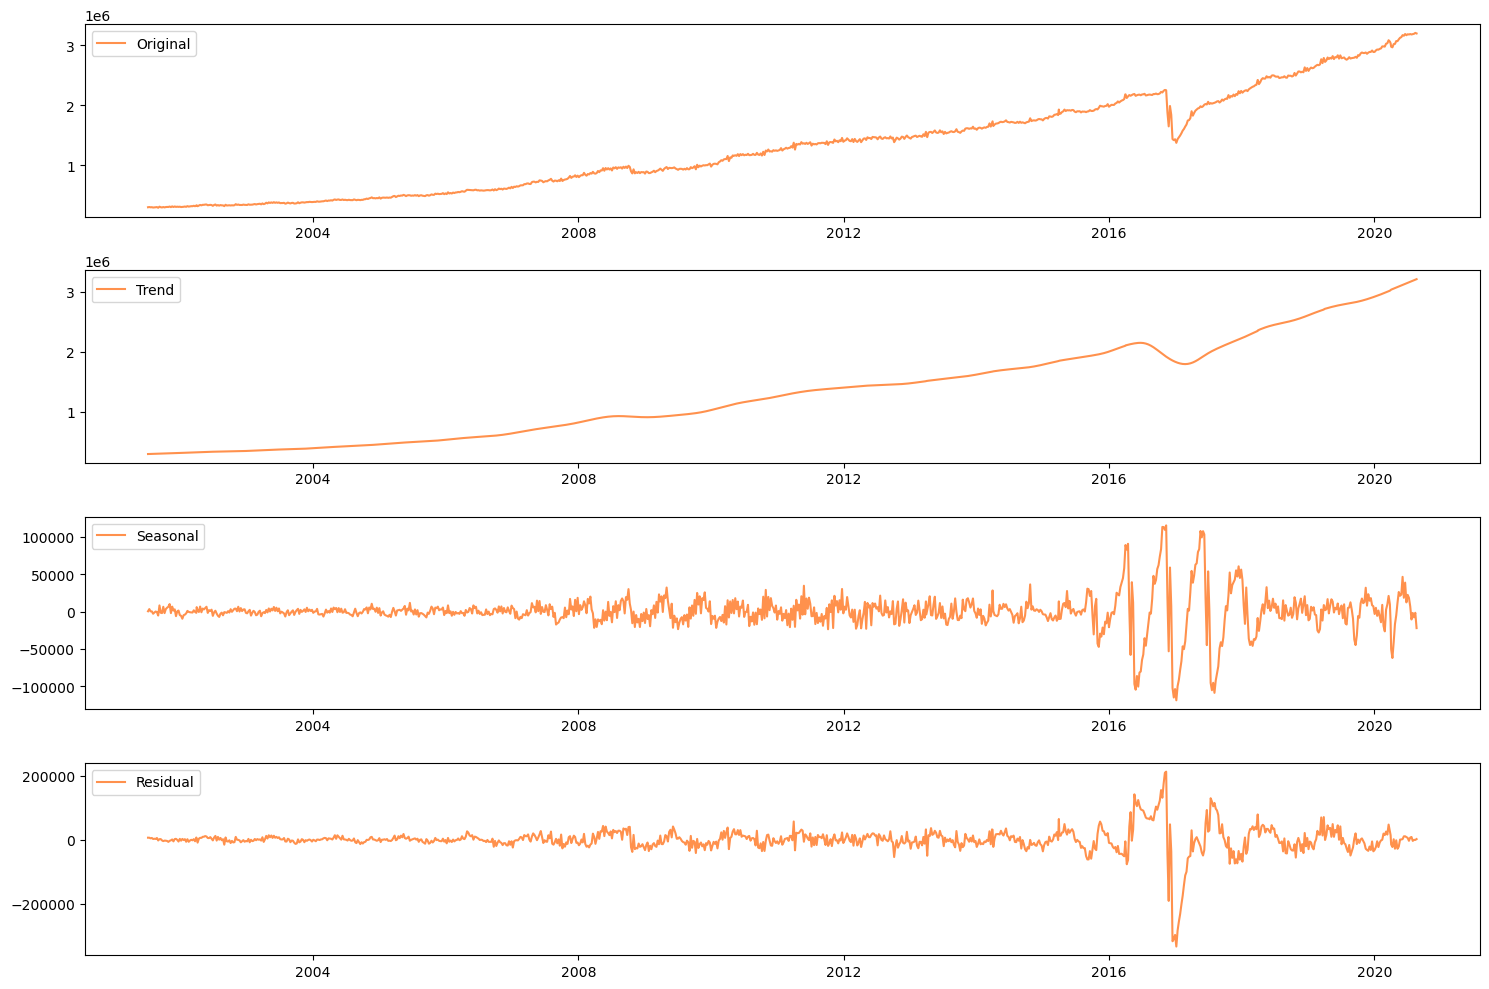

In [213]:
# Plot the decomposition components
plt.figure(figsize = (15,10))
plt.subplot(411)
plt.plot(result.observed, label = 'Original', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(result.trend, label = 'Trend', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(result.seasonal, label = 'Seasonal', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(result.resid, label = 'Residual', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig('STL3')
plt.show()

### Seasonal Decomposition Analysis of Reserve Money:
1. Shows steady growth over time, with a sharp dip around 2016, likely due to demonetization.
2. Seasonal fluctuations remain relatively stable until 2016, after which volatility increases significantly.
3. The post-2016 period shows extreme seasonal swings, likely due to monetary policy interventions.
4. Residuals are stable before 2016 but show a sharp downward spike during demonetization.

### 4. Net Foreign Exchange Assets of RBI: Seasonal Decomposition Analysis
Here we use STL Decomposition, as from the trend plot it is clear that the seasonal variation is not directly proportonal to Net Foreign Exchange Assets. So we can conclude this as an additive model.

In [215]:
from statsmodels.tsa.seasonal import STL

# Perfrom STL decomposition
stl = STL(data['Net_foreign_exchange_assets_of_RBI'], period = 30)
result = stl.fit()

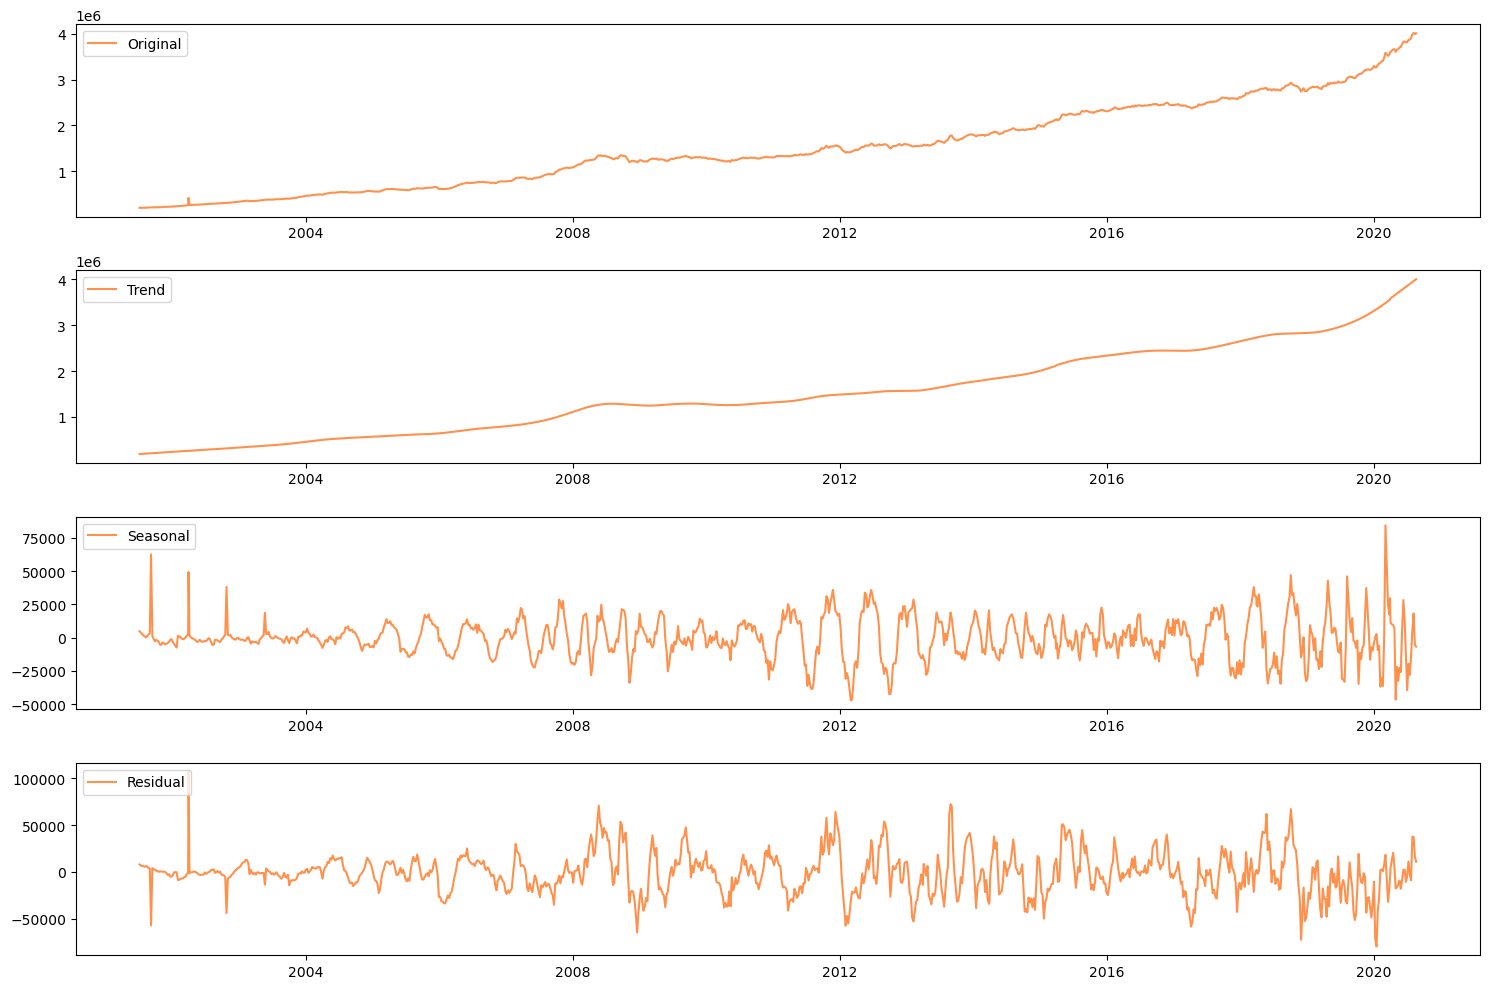

In [217]:
plt.figure(figsize = (15,10))
plt.subplot(411)
plt.plot(result.observed, label = 'Original', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(412)
plt.plot(result.trend, label = 'Trend', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(413)
plt.plot(result.seasonal, label = 'Seasonal', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.subplot(414)
plt.plot(result.resid, label = 'Residual', color = '#FF914D')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.savefig('STL4')
plt.show()

### Seasonal Decomposition Analysis of Net Foreign Exchange Assets of RBI:
1. The growth accelerates after 2019, possibly due to higher capital inflows and RBI's forex interventions.
2. Exhibits regular fluctuations with noticeable spikes at specific intervals, indicating seasonal variations in forex reserves.
3. The magnitude of seasonal variations increases post-2010, suggesting higher forex market activity and interventions.
4. Shows moderate volatility, with occasional spikes indicating external shocks or policy changes.